In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import itertools
import os

from clumppling.plot import plot_alignment_graph
from ace_of_clust.plot import make_mode_grid_by_K
import ace_of_clust as aoc

Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'bayanpy', 'infomap', 'graph_tool'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'infomap'}


## Paths & Data

In [3]:
base_dir         = Path("/users/xliu293/data/users/xliu293/ace-of-clust")
example_data_dir = base_dir / "examples" / "data" / "pbmc3k"

cls_dir   = example_data_dir / "clustering" / "full_mmc"
align_dir = example_data_dir / "aligned"    / "full_mmc"

In [4]:
umap_coords = np.loadtxt(example_data_dir / "scanpy_tutorial_umap.txt", delimiter=" ")

tutorial_labels = np.loadtxt(
    example_data_dir / "scanpy_tutorial_labels.txt", dtype=str, delimiter="\t"
)
tutorial_Q = np.loadtxt(example_data_dir / "reference" / "scanpy_tutorial.Q", delimiter=" ")
cell_type_labels = np.array([tutorial_labels[i] for i in np.argmax(tutorial_Q, axis=1)])

gene_names = np.loadtxt(
    example_data_dir / "clustering" / "test" / "full_mmc" / "fasttopics_mmc_genes.txt",
    dtype=str,
)
print(f"{len(gene_names)} genes, {len(cell_type_labels)} cells")

cb_cmap = [
    '#E69F00', '#009E73', '#CC79A7', '#56B4E9',
    '#F0E442', '#D55E00', '#0072B2', '#7F68A1',
    '#A3C644', '#FF1493', '#8B4513', '#20B2AA',
    '#9400D3', '#FF8C00',
]

13713 genes, 2638 cells


In [5]:
results = aoc.load_clumppling_results(
    align_dir = align_dir,
    suffix    = "rep",
    cls_dir   = cls_dir,
    load_P    = True,
    strict_P  = False,
)

# Compute per-gene metrics for all modes (used in gene analysis below)
df_by_mode = aoc.compute_all_feature_metrics(results, feature_names=gene_names)

# Reorder cells by cell-type label for structure plots
cell_labels_ordered_indices = np.argsort(cell_type_labels)
cell_labels_ordered         = cell_type_labels[cell_labels_ordered_indices]
umap_coords_ordered         = umap_coords[cell_labels_ordered_indices]

results_ordered = results
tmp_Q = results_ordered.Q_by_mode.copy()
for mode in results_ordered.modes:
    tmp_Q[mode] = tmp_Q[mode][cell_labels_ordered_indices]
results_ordered.Q_by_mode          = tmp_Q
results_ordered.Q_unaligned_by_mode = tmp_Q

# Subset to first 9 modes
sub_full = aoc.subset_results(results_ordered, results_ordered.modes[:9])
print("Subset modes:", sub_full.modes)

Subset modes: ['K2M1', 'K3M1', 'K4M1', 'K5M1', 'K5M2', 'K6M1', 'K7M1', 'K8M1', 'K8M2']


## Reference: Scanpy Tutorial Cell Types

Text(0, 0.5, 'UMAP 2')

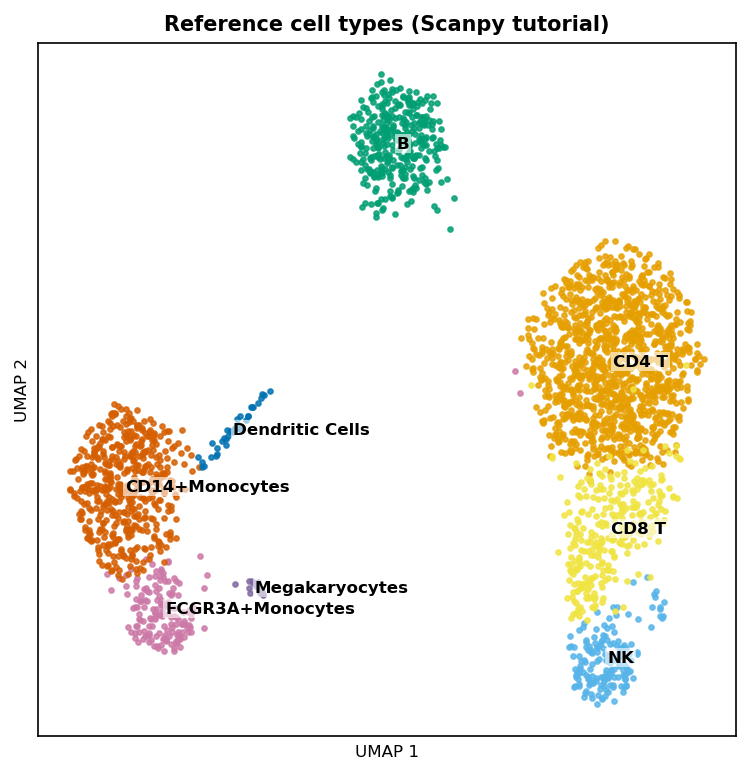

In [6]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
for i, cell_type in enumerate(tutorial_labels):
    mask = cell_type_labels == cell_type
    ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1],
               s=5, color=cb_cmap[i % len(cb_cmap)], alpha=0.8, label=cell_type)
    ax.text(np.mean(umap_coords[mask, 0]), np.mean(umap_coords[mask, 1]),
            cell_type,
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1),
            fontsize=8, ha="left", va="center", color="black", weight="bold")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Reference cell types (Scanpy tutorial)", fontsize=10, weight="bold")
ax.set_xlabel("UMAP 1", fontsize=8)
ax.set_ylabel("UMAP 2", fontsize=8)

## Parameters

Tag this cell with `parameters` for papermill. Override `gs_name`, `gs_file`, `gs_mode`, and `n_perm` per run.

In [44]:
gs_name  = "Cytotoxic lymphocyte program"
gs_file  = str(example_data_dir / "gene_sets" / "B_cell_program.txt")
gs_mode  = "K6M1"   # mode name from sub_full.modes
n_perm   = 10_000
rng_seed = 1        # fixed for reproducibility

## Load Gene Set

In [45]:
gs_raw = np.loadtxt(Path(gs_file), dtype=str)
gene_set, gene_set_indices = aoc.resolve_gene_set(gs_raw.tolist(), gene_names)
print(f"{len(gene_set)} / {len(gs_raw)} genes matched for {gs_name}:\n{', '.join(gene_set)}")

6 / 6 genes matched for Cytotoxic lymphocyte program:
MS4A1, CD79A, CD79B, CD37, HLA-DRA, CD74


---
## Single-Mode Analysis

### Mode & P-Matrix Setup

In [46]:
K_mode         = sub_full.mode_K[gs_mode]
df_mode        = df_by_mode[gs_mode]
cluster_labels = [f"Cls.{i+1}" for i in range(K_mode)]
cluster_colors = cb_cmap[:K_mode]
gs_title       = f"{gs_name}  (mode {gs_mode})"
print(f"gs_mode: {gs_mode}  |  K={K_mode}")
print(f"cluster_labels: {cluster_labels}")

# Relative expression matrix P: G×K; restrict to gene-set rows
P    = sub_full.P_aligned_by_mode[gs_mode]   # (G, K)
P_gs = P[gene_set_indices]                   # (|S|, K)
print(f"P shape: {P.shape}  |  P_gs shape: {P_gs.shape}")

gs_mode: K6M1  |  K=6
cluster_labels: ['Cls.1', 'Cls.2', 'Cls.3', 'Cls.4', 'Cls.5', 'Cls.6']
P shape: (13713, 6)  |  P_gs shape: (6, 6)


### Compute Null Distribution & Run Tests

B random gene sets of size |S| are drawn (without replacement) to form the shared null.
All three tests compare observed statistics to this null via empirical p-values
p_emp = (1 + #{b: null ≥ obs}) / (B + 1).

- **P enrichment** – observed gene-set average relative expression p̄ˢ per cluster k vs. null
- **Pairwise LFC enrichment** – pwLFC_{kk'} = log₂p̄ˢ_k − log₂p̄ˢ_{k'} vs. null (BH-corrected)
- **SepLFC** – largest LFC gap across clusters sorted by p̄ˢ; clusters below/above the gap form L/H

In [47]:
# Sample B random gene sets of size |S| → shared null mean-P vectors
null_mean_P = aoc.sample_null_P(P, gene_set_indices, n_perm, rng_seed)

# 1. P enrichment: compare p̄ˢ_k to null; report z-score and empirical p-value
p_res = aoc.test_P_enrichment(P, gene_set_indices, null_mean_P)
print("gs_mean_P:", dict(zip(cluster_labels, p_res["gs_mean_P"].round(6))))
print("p_emp:    ", dict(zip(cluster_labels, p_res["p_emp"].round(4))))

# 2. Pairwise LFC: pwLFC_{kk'} vs. null (BH-corrected q-values)
lfc_res = aoc.test_LFC_enrichment(P, gene_set_indices, null_mean_P)

# 3. SepLFC: largest LFC gap in p̄ˢ-sorted clusters; tested against two nulls
sep_res = aoc.test_sepLFC_enrichment(P, gene_set_indices, null_mean_P)
print(f"\nsepLFC          = {sep_res['gs_sepLFC']:.4f}")
print(f"geometric sepLFC = {sep_res['gs_geomean_LFC']:.4f}")
print(f"  low:  {[cluster_labels[k] for k in sep_res['sepL']]}")
print(f"  high: {[cluster_labels[k] for k in sep_res['sepH']]}")
print(f"  p (vs null best):           {sep_res['p_vs_null_sep']:.4e}")
print(f"  p (vs null fixed clusters): {sep_res['p_vs_null_fixed']:.4e}")

gs_mean_P: {'Cls.1': 0.000134, 'Cls.2': 0.001345, 'Cls.3': 0.000269, 'Cls.4': 0.008293, 'Cls.5': 0.001452, 'Cls.6': 0.000268}
p_emp:     {'Cls.1': 0.0639, 'Cls.2': 0.0075, 'Cls.3': 0.0342, 'Cls.4': 0.0001, 'Cls.5': 0.005, 'Cls.6': 0.0511}

sepLFC          = 2.5141
geometric sepLFC = 8.4798
  low:  ['Cls.1', 'Cls.6', 'Cls.3', 'Cls.2', 'Cls.5']
  high: ['Cls.4']
  p (vs null best):           4.2396e-02
  p (vs null fixed clusters): 4.1996e-03


### P Enrichment

Left: one-sided empirical p-value per cluster k.  
Right: z-score z_k = (p̄ˢ_k − μᵐᵘˡˡ_k) / σᵐᵘˡˡ_k.

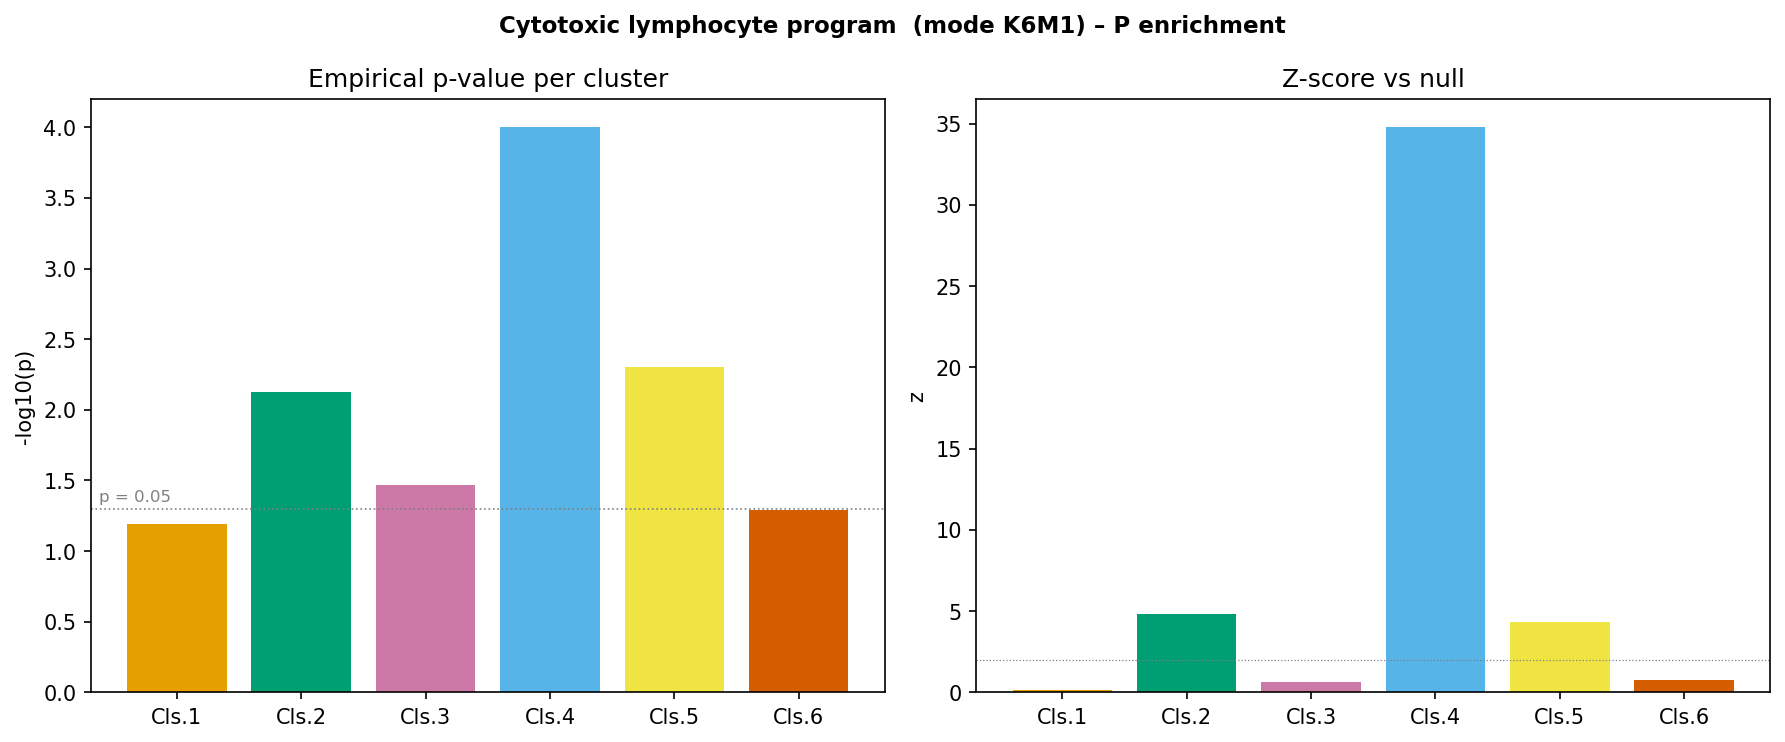

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)
aoc.plot_P_enrichment_pval(p_res, cluster_labels, cluster_colors, ax=axes[0])
aoc.plot_P_enrichment_zscore(p_res, cluster_labels, cluster_colors, ax=axes[1])
fig.suptitle(f"{gs_title} – P enrichment", fontsize=11, weight="bold")
fig.tight_layout()

### Pairwise LFC Enrichment

pwLFC_{kk'} = log₂p̄ˢ_k − log₂p̄ˢ_{k'} tested two-sided against its null; p-values are
BH-corrected.

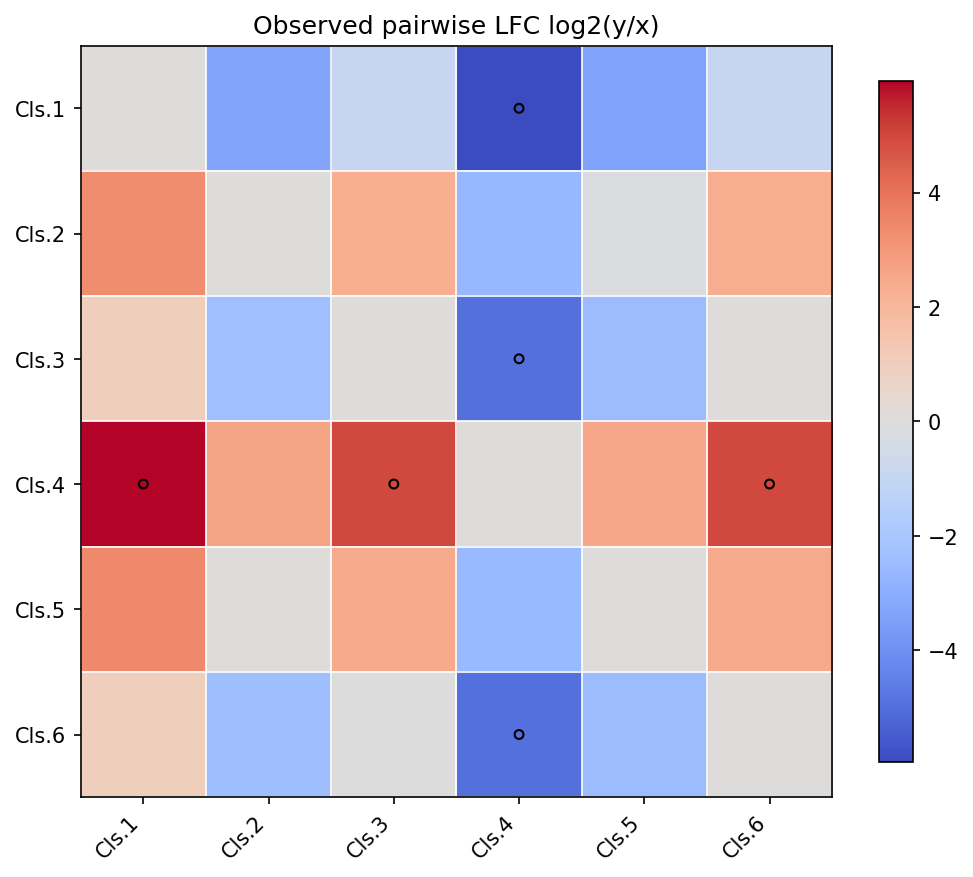

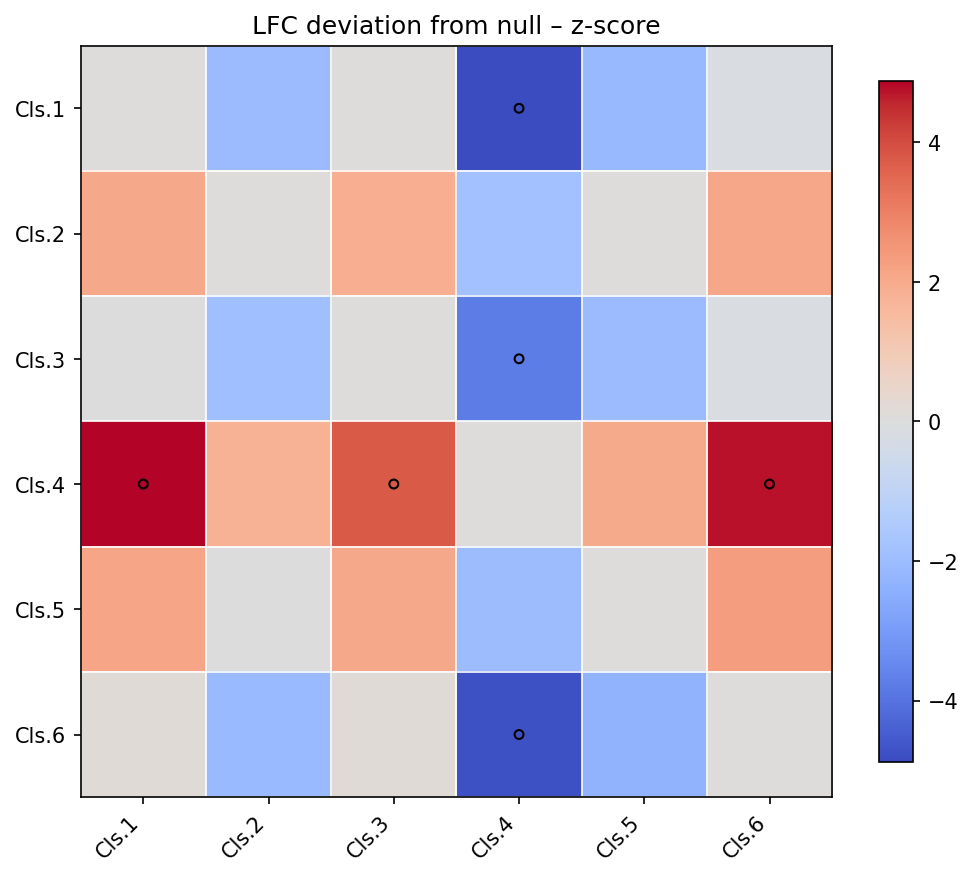

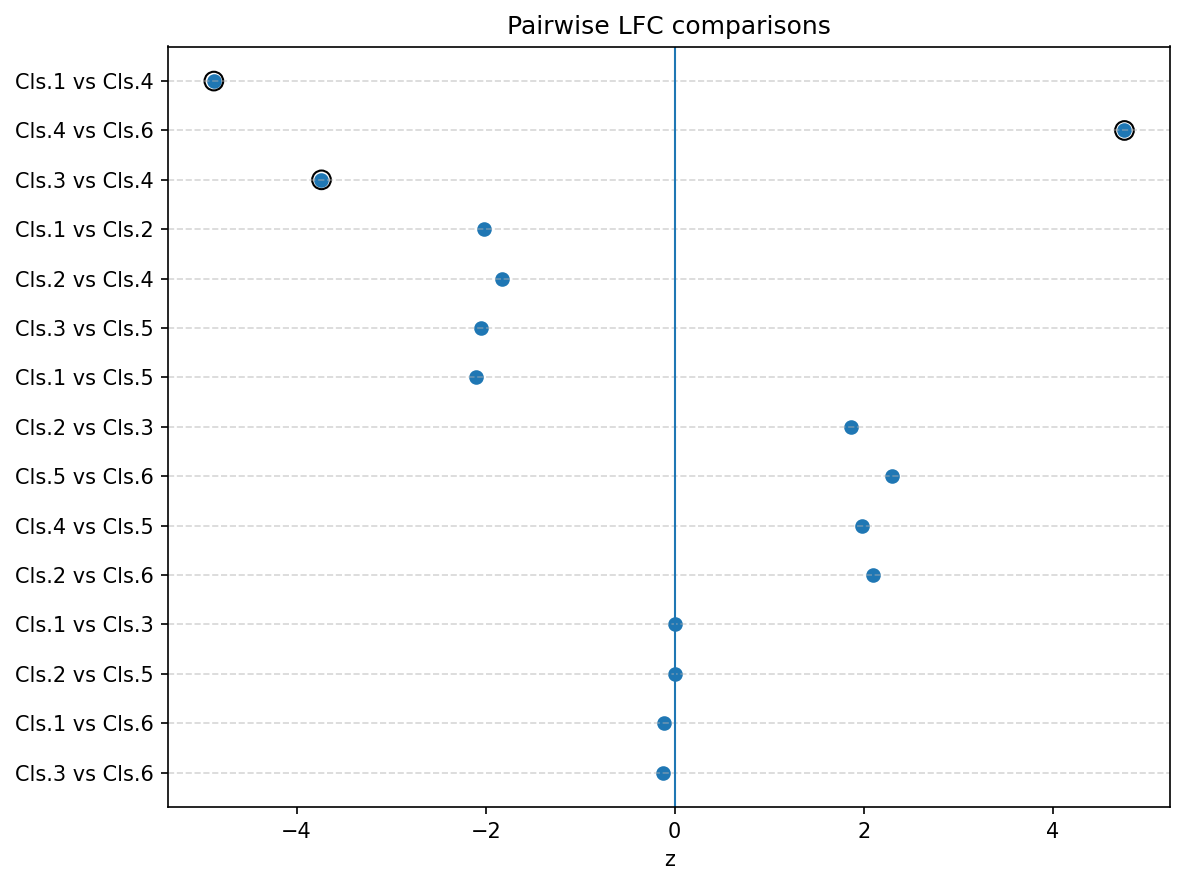

In [49]:
fig1, _ = aoc.plot_pairwise_heatmap(
    lfc_res["obs_lfc"], sig_mat=lfc_res["test"]["q_mat"],
    labels=cluster_labels, title="Observed pairwise LFC log2(y/x)", upper_only=False,
)
fig2, _ = aoc.plot_pairwise_heatmap(
    lfc_res["test"]["z_mat"], sig_mat=lfc_res["test"]["q_mat"],
    labels=cluster_labels, title="LFC deviation from null – z-score", upper_only=False,
)
fig3, _ = aoc.plot_top_pairwise_df(
    lfc_res["df"], value_col="z", sig_col="q", alpha=0.05, labels=cluster_labels,
)

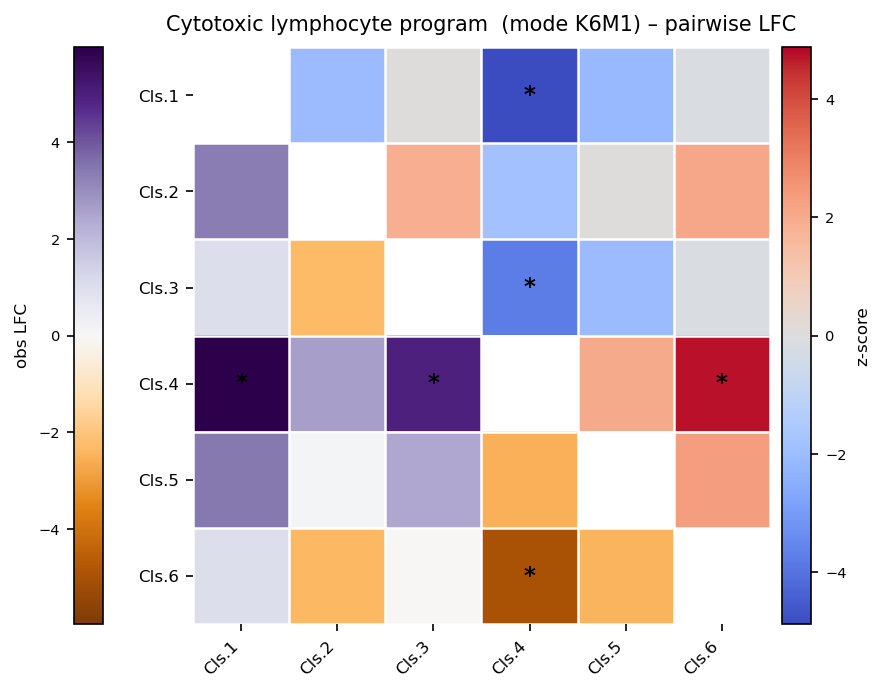

In [50]:
fig, ax = aoc.plot_pairwise_heatmap_bidir(
    upper_mat=lfc_res["test"]["z_mat"],
    lower_mat=lfc_res["obs_lfc"],
    upper_sig=lfc_res["test"]["q_mat"],
    lower_sig=lfc_res["test"]["q_mat"],
    upper_label="z-score",
    lower_label="obs LFC",
    labels=cluster_labels,
    title=f"{gs_title} – pairwise LFC",
)

### Separating LFC (SepLFC)

Clusters are sorted by p̄ˢ_k; the largest LFC gap defines the L/H bipartition.

Left: observed sepLFC vs. *null best sepLFC* — largest gap from each null set.  
Right: observed sepLFC vs. *null LFC at fixed clusters* — δ⁽ᵇ⁾ = log₂ min_{k∈H} p̄⁽ᵇ⁾_k − log₂ max_{k∈L} p̄⁽ᵇ⁾_k.

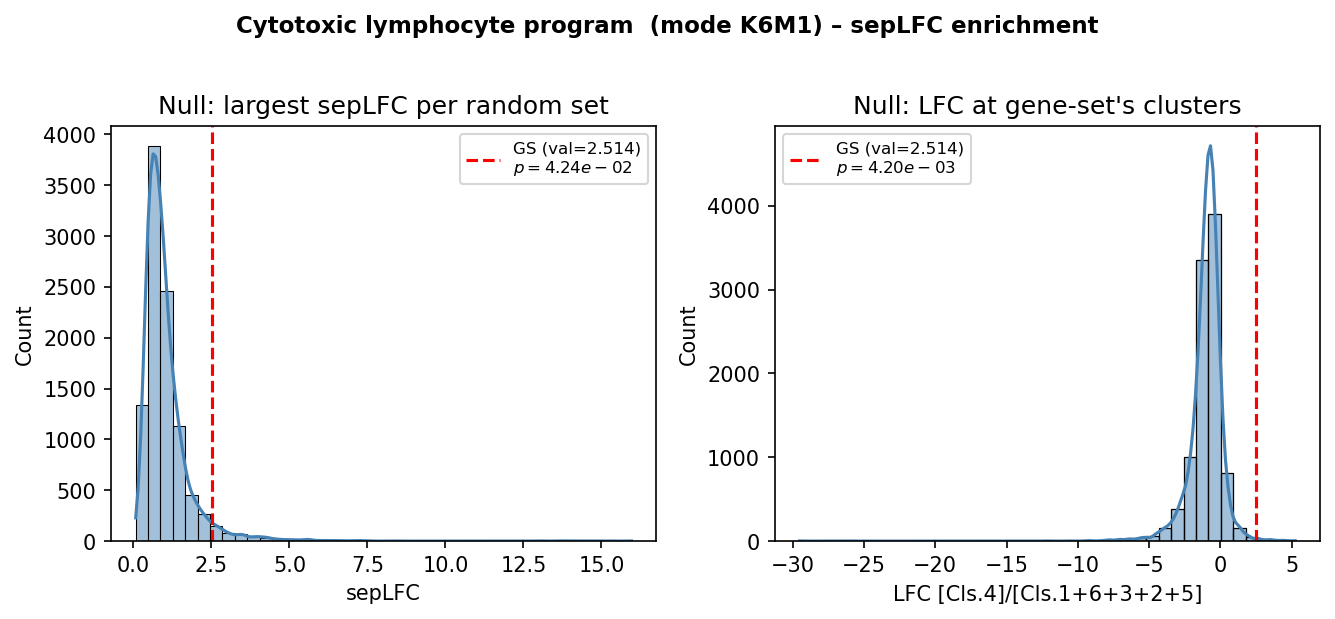

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), dpi=150)
aoc.plot_sepLFC_null_sep(sep_res, ax=axes[0])
aoc.plot_sepLFC_null_fixed(sep_res, cluster_labels, ax=axes[1])
fig.suptitle(f"{gs_title} – sepLFC enrichment", fontsize=11, weight="bold", y=1.02)
fig.tight_layout()

### Per-Gene P

Visualize relative expression of gene-set genes across clusters.

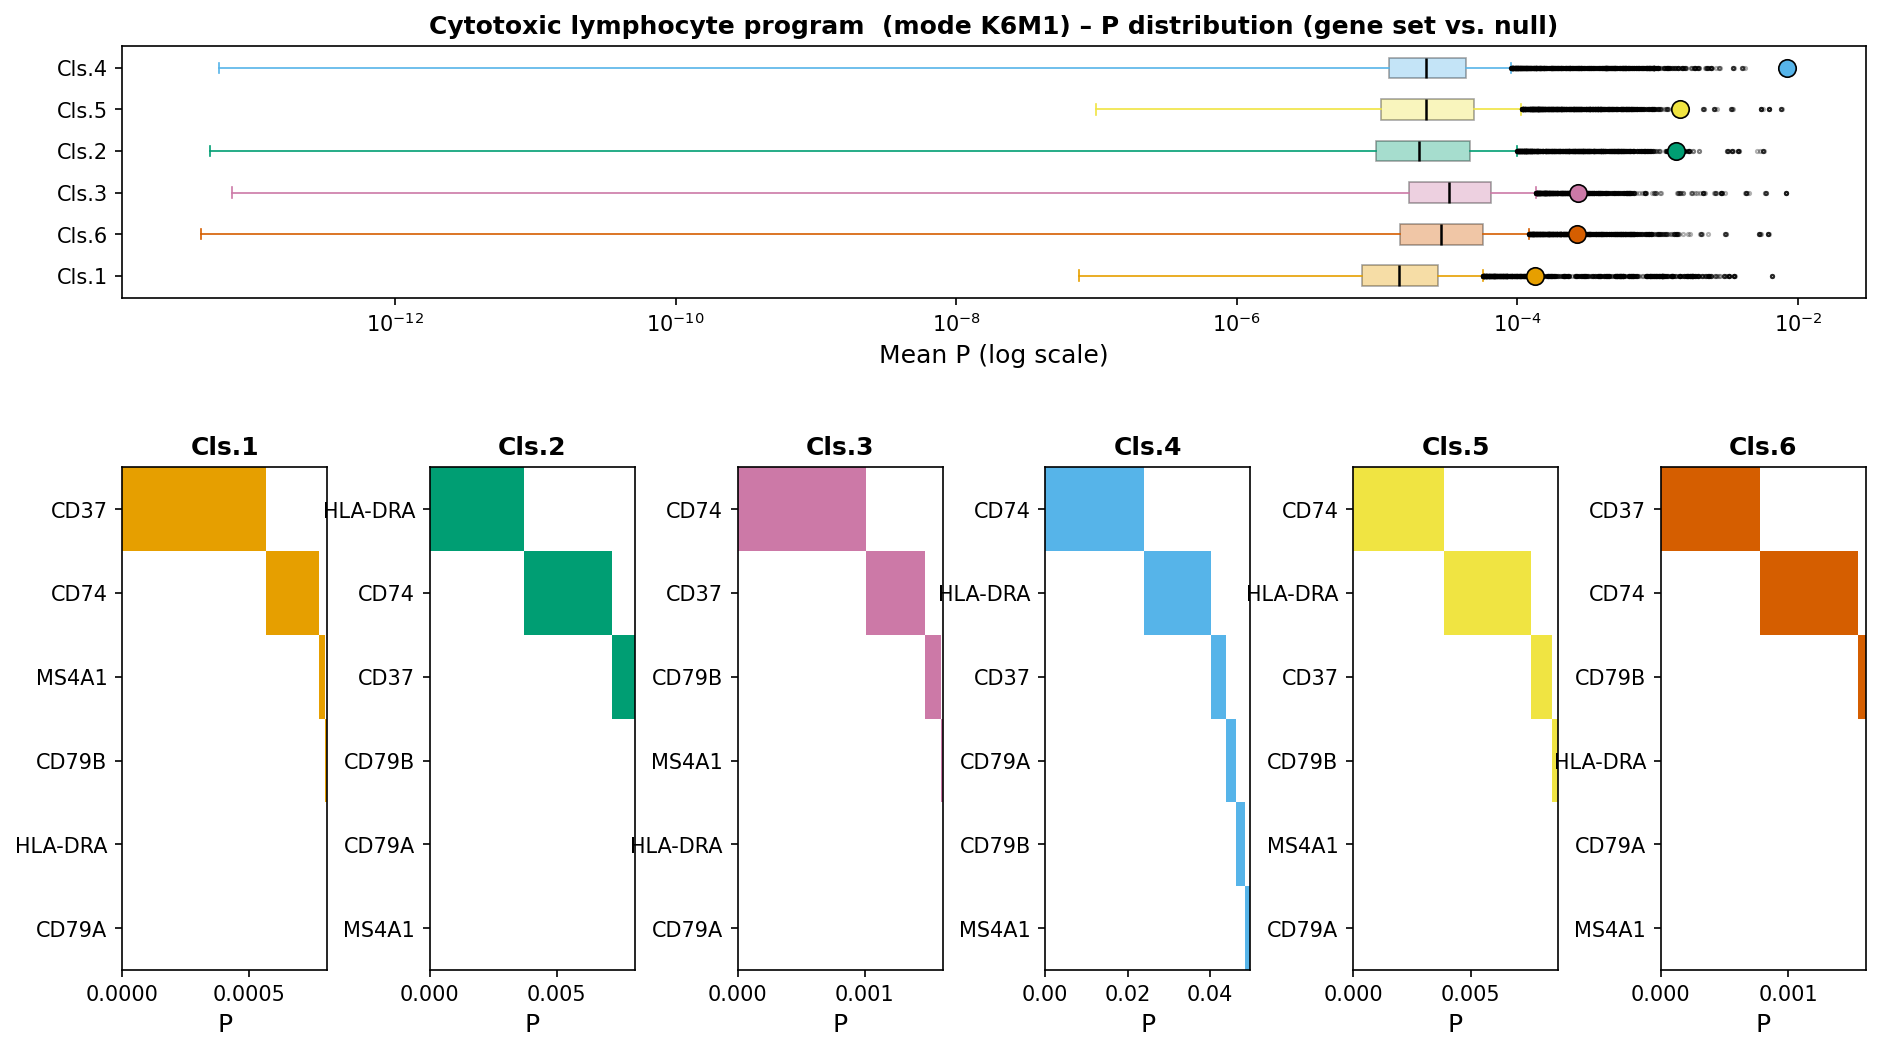

In [52]:
fig, ax_top, axes_bottom = aoc.plot_per_cluster_P(
    P_gs, gene_set, cluster_labels, cluster_colors,
    null_mean_P=null_mean_P,   # shape (n_perm, K) from sample_null_P()
    gs_title=gs_title,
)

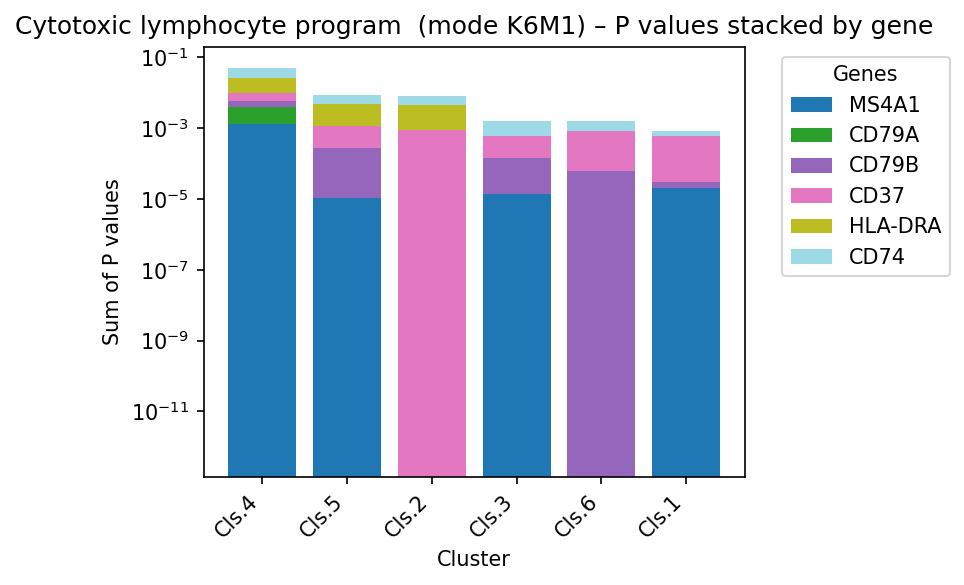

In [53]:
fig, ax = aoc.plot_gene_P_stacked(
    P_gs, gene_set, cluster_labels, gs_title=gs_title, sort_by_sum=True, top_n=10
)

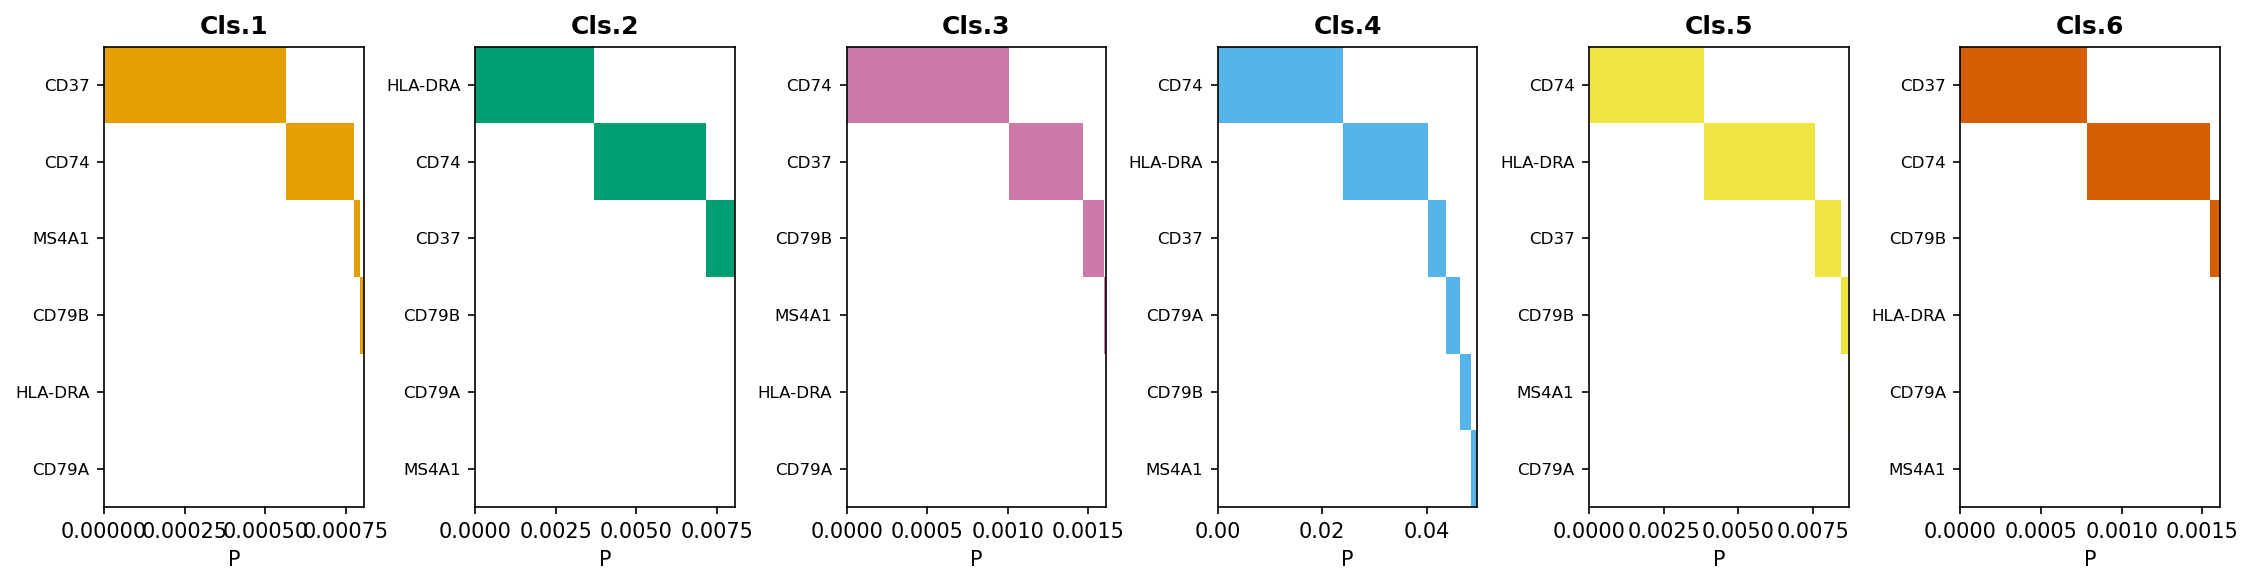

In [54]:
fig, _ = aoc.plot_gene_P_bars(P_gs, gene_set, cluster_labels, cluster_colors, top_n=10)

### Gene Analysis

Per-gene LFC between the gene set's separating clusters (L/H), ranked by contribution.

In [55]:
df_sepCls = aoc.analyze_sep_genes(df_mode, sep_res['sepH'], sep_res['sepL'],
                                  gene_set, top_n=15)
df_sepCls['gene'] = df_sepCls.index

sepCls ordered:   ((0, 5, 2, 1, 4), (3,))  |  n_genes (all): 2
sepCls unordered: 120 permutations  |  n_genes (all): 206
gene_set matches: 3 / 6  |  returning top 3


In [56]:
sepL_t = tuple(int(x) for x in sep_res['sepL'])
sepH_t = tuple(int(x) for x in sep_res['sepH'])

# Ordered match: sepCls == (sepL, sepH) exactly
sepCls_ordered   = (sepL_t, sepH_t)
df_sep_ordered   = df_mode[df_mode['sepCls'] == sepCls_ordered].copy()

# Unordered match: any permutation of sepL and sepH groups
sepCls_unordered = {
    (permL, permH)
    for permL in itertools.permutations(sepL_t)
    for permH in itertools.permutations(sepH_t)
}
df_sep_unordered = df_mode[df_mode['sepCls'].apply(lambda x: x in sepCls_unordered)].copy()

for _df in [df_sep_ordered, df_sep_unordered]:
    _df['rank_sepLFC'] = _df['sepLFC'].rank(ascending=False, method='min').astype(int)
df_sep_ordered   = df_sep_ordered.sort_values('sepLFC', ascending=False)
df_sep_unordered = df_sep_unordered.sort_values('sepLFC', ascending=False)

print(f"Genes in ordered sepCls:   {len(set(df_sep_ordered.index)  & set(gene_set))} / {len(gene_set)}")
print(f"Genes in unordered sepCls: {len(set(df_sep_unordered.index) & set(gene_set))} / {len(gene_set)}")

Genes in ordered sepCls:   1 / 6
Genes in unordered sepCls: 3 / 6


Text(0.5, 0.94, 'Cytotoxic lymphocyte program  (mode K6M1)')

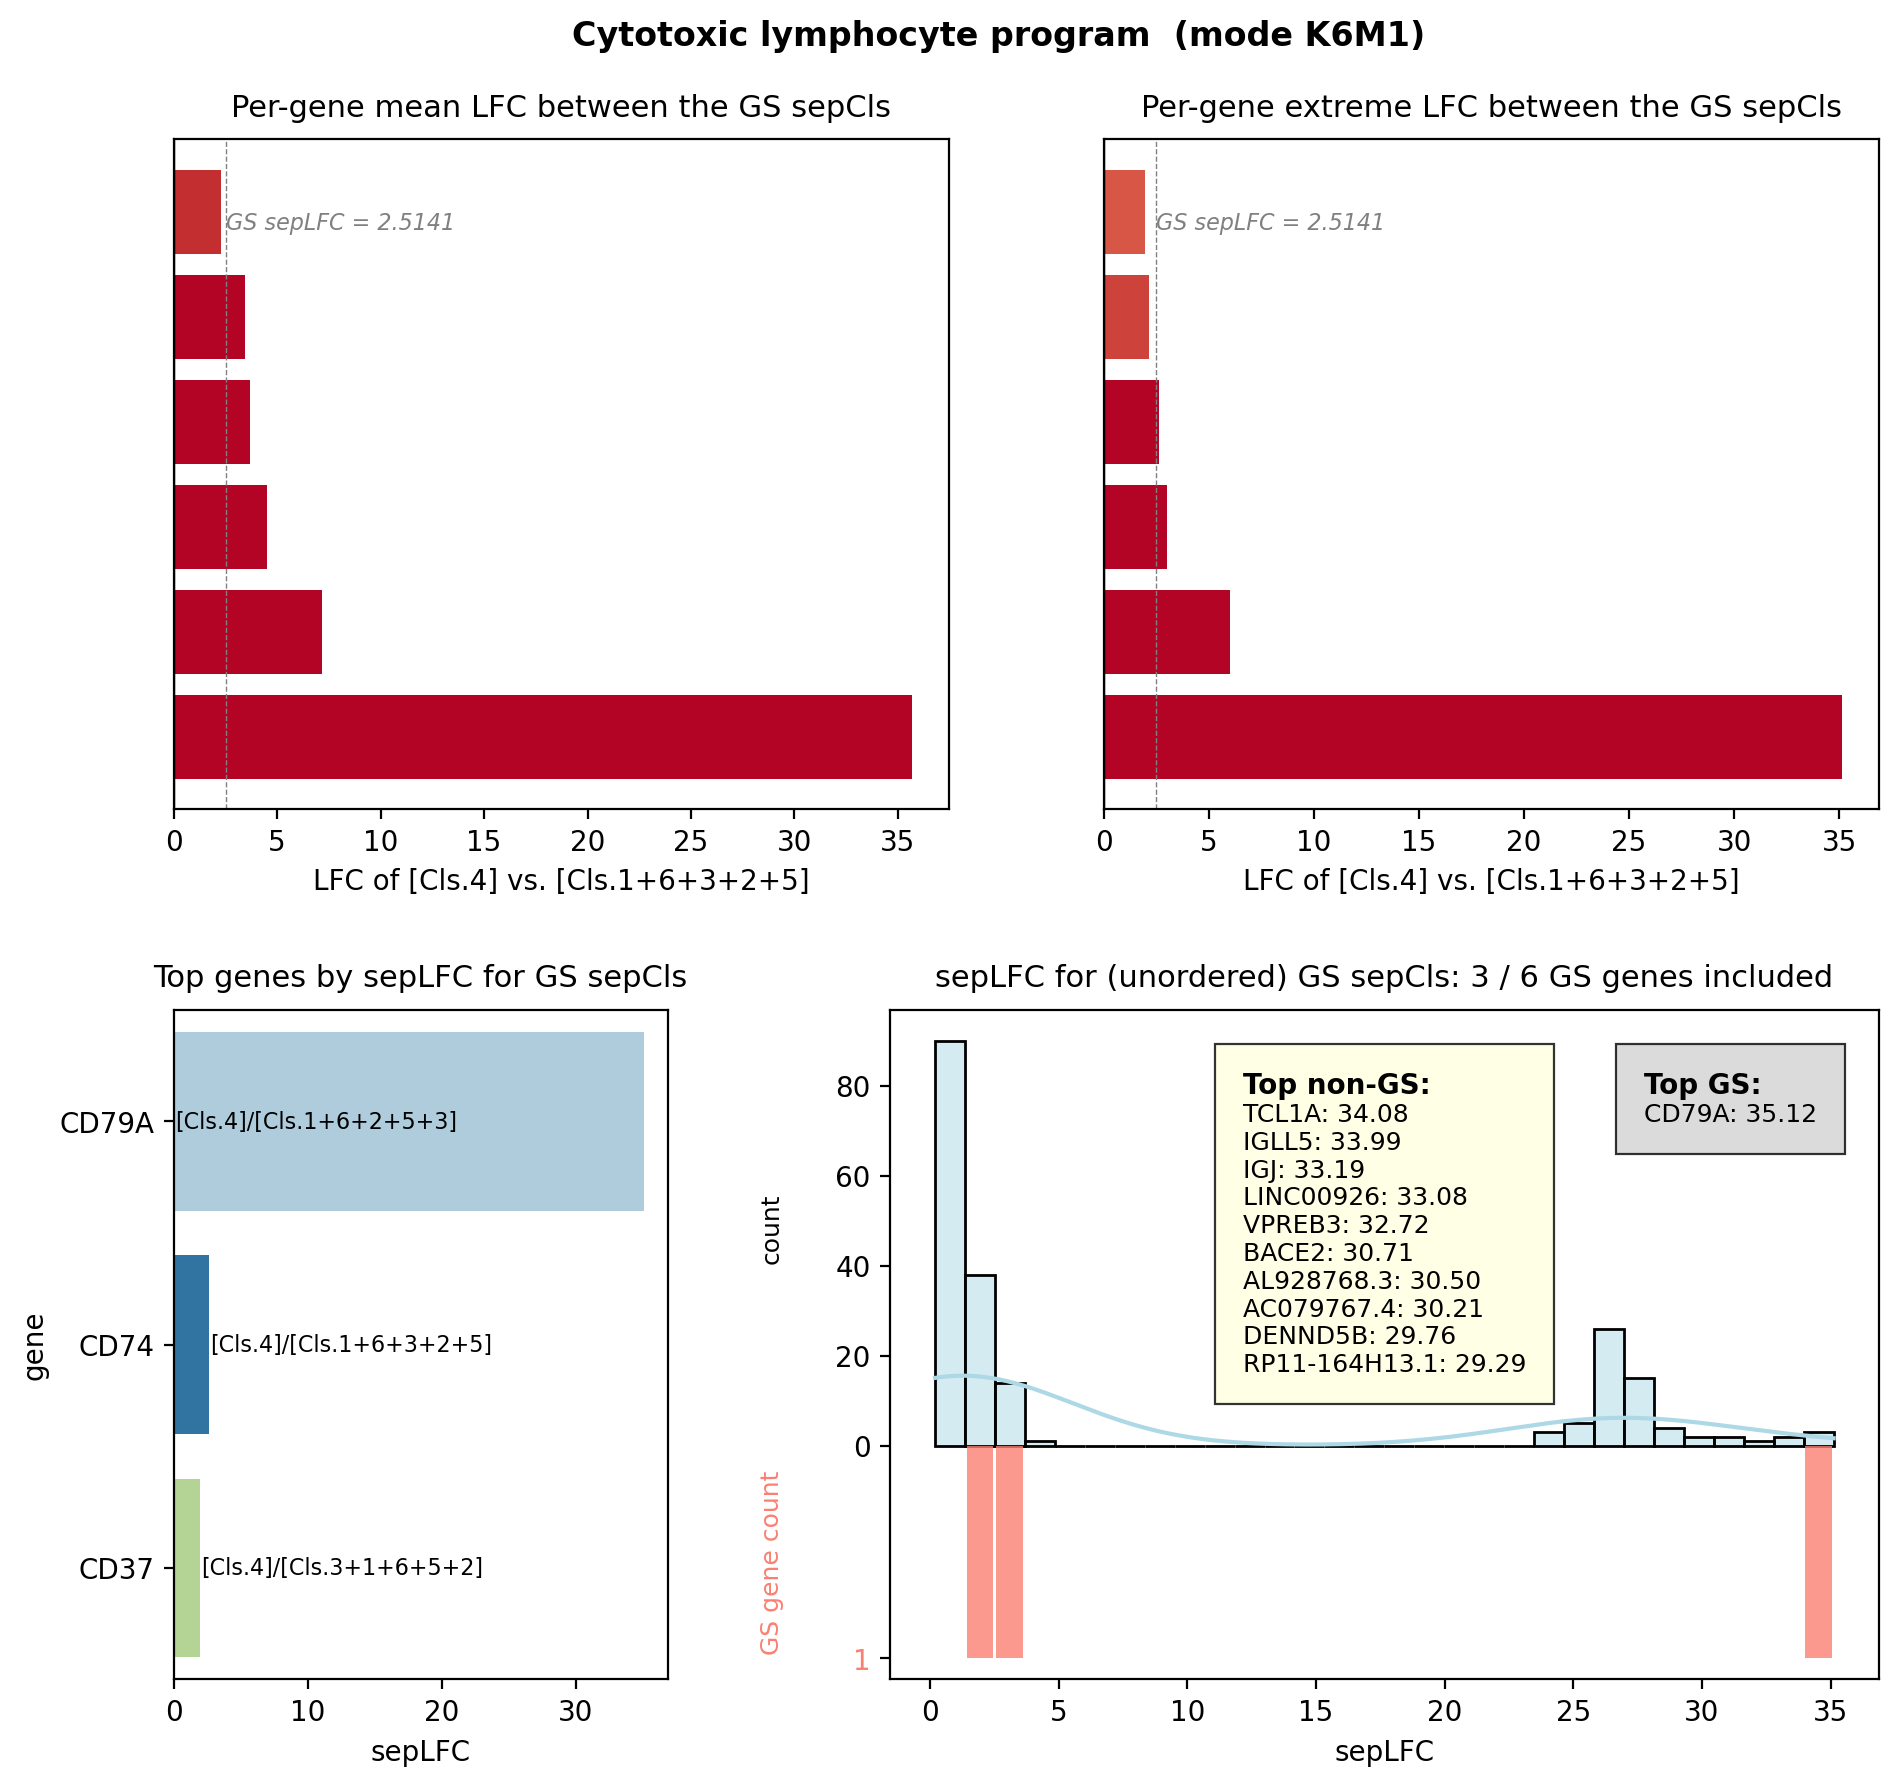

In [57]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

fig = plt.figure(figsize=(11, 10), dpi=200)
gs  = GridSpec(2, 1, figure=fig, hspace=0.3)

gs_top = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0], wspace=0.2)
gs_bot = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1], wspace=0.3, width_ratios=[1, 2])

# ── TL: per-gene mean LFC ──────────────────────────────────────────────────────
ax   = fig.add_subplot(gs_top[0])
kind = "mean"
df_gene_lfc = aoc.compute_gene_lfc(P_gs, gene_set, sep_res["sepL"], sep_res["sepH"], kind=kind)
aoc.plot_gene_lfc(df_gene_lfc, cluster_labels, sep_res["sepL"], sep_res["sepH"],
                  sep_res["gs_sepLFC"], cluster_colors, kind=kind, show_labels=False, ax=ax)
ax.axvline(0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(sep_res["gs_sepLFC"], color='gray', linestyle='--', linewidth=0.5)
ax.text(sep_res["gs_sepLFC"], len(gene_set)-1, f"GS sepLFC = {sep_res['gs_sepLFC']:.4f}",
        ha="left", va="top", fontsize=8, color="gray", style="italic")
ax.set_title(f"Per-gene {kind} LFC between the GS sepCls", fontsize=11, weight='normal', y=1.01)

# ── TR: per-gene extreme LFC ──────────────────────────────────────────────────
ax   = fig.add_subplot(gs_top[1])
kind = "extreme"
df_gene_lfc = aoc.compute_gene_lfc(P_gs, gene_set, sep_res["sepL"], sep_res["sepH"], kind=kind)
aoc.plot_gene_lfc(df_gene_lfc, cluster_labels, sep_res["sepL"], sep_res["sepH"],
                  sep_res["gs_sepLFC"], cluster_colors, kind=kind, show_labels=False, ax=ax)
ax.axvline(0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(sep_res["gs_sepLFC"], color='gray', linestyle='--', linewidth=0.5)
ax.text(sep_res["gs_sepLFC"], len(gene_set)-1, f"GS sepLFC = {sep_res['gs_sepLFC']:.4f}",
        ha="left", va="top", fontsize=8, color="gray", style="italic")
ax.set_title(f"Per-gene {kind} LFC between the GS sepCls", fontsize=11, weight='normal', y=1.01)

# ── BL: top genes by sepLFC ───────────────────────────────────────────────────
ax = fig.add_subplot(gs_bot[0])
sns.barplot(x='sepLFC', y='gene', data=df_sepCls, hue='sepCls', palette='Paired',
            ax=ax, legend=False)
existing_labels = set()
for i_gene, row in df_sepCls.iterrows():
    low_str  = "Cls."+"+".join(str(k+1) for k in row['sepCls'][0])
    high_str = "Cls."+"+".join(str(k+1) for k in row['sepCls'][1])
    sep_cls  = f"[{high_str}]/[{low_str}]"
    if sep_cls in existing_labels:
        sep_cls = ""
    else:
        existing_labels.add(sep_cls)
    if row['sepLFC'] > 10 or max(df_sepCls['sepLFC']) < 15:
        ax.text(0.1, i_gene, sep_cls, rotation=0, ha='left', va='center', fontsize=8)
    else:
        ax.text(row['sepLFC'] + 0.1, i_gene, sep_cls, rotation=0, ha='left', va='center', fontsize=8)
if len(df_sepCls) < 2:
    x_max = max(df_sepCls['sepLFC']) * 1.5
    ax.set_xlim(0, x_max)
    ax.set_ylim(-1.5, len(df_sepCls) + 0.5)
ax.set_title("Top genes by sepLFC for GS sepCls", fontsize=11, weight='normal', y=1.01)

# ── BR: sepLFC distribution ───────────────────────────────────────────────────
ax = fig.add_subplot(gs_bot[1])
aoc.plot_sepLFC_distribution(
    df_sep_unordered, gene_set, title="", kind="auto",
    show_gs_textbox=True, gs_textbox_threshold=10, n_gs_textbox=10,
    show_non_gs_textbox=True, n_non_gs_textbox=10, ax=ax,
)
ax.set_title(
    f"sepLFC for (unordered) GS sepCls: "
    f"{len(set(df_sep_unordered.index) & set(gene_set))} / {len(gene_set)} GS genes included",
    fontsize=11, weight='normal', y=1.01
)

fig.suptitle(f"{gs_title}", fontsize=12, weight='bold', y=0.94)

In [58]:
print("Top non-GS genes by sepLFC in unordered sepCls:")
print(df_sep_unordered[~df_sep_unordered.index.isin(gene_set)].head(10).index)

Top non-GS genes by sepLFC in unordered sepCls:
Index(['TCL1A', 'IGLL5', 'IGJ', 'LINC00926', 'VPREB3', 'BACE2', 'AL928768.3',
       'AC079767.4', 'DENND5B', 'RP11-164H13.1'],
      dtype='object')


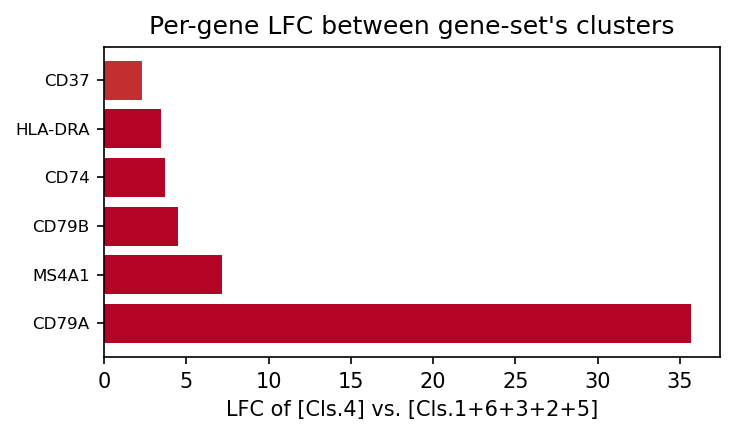

In [59]:
df_gene_lfc = aoc.compute_gene_lfc(
    P_gs, gene_set, sep_res["sepL"], sep_res["sepH"], kind="mean"
)
fig, ax = aoc.plot_gene_lfc(
    df_gene_lfc, cluster_labels,
    sep_res["sepL"], sep_res["sepH"],
    sep_res["gs_sepLFC"], cluster_colors, kind="mean", show_labels=True,
)

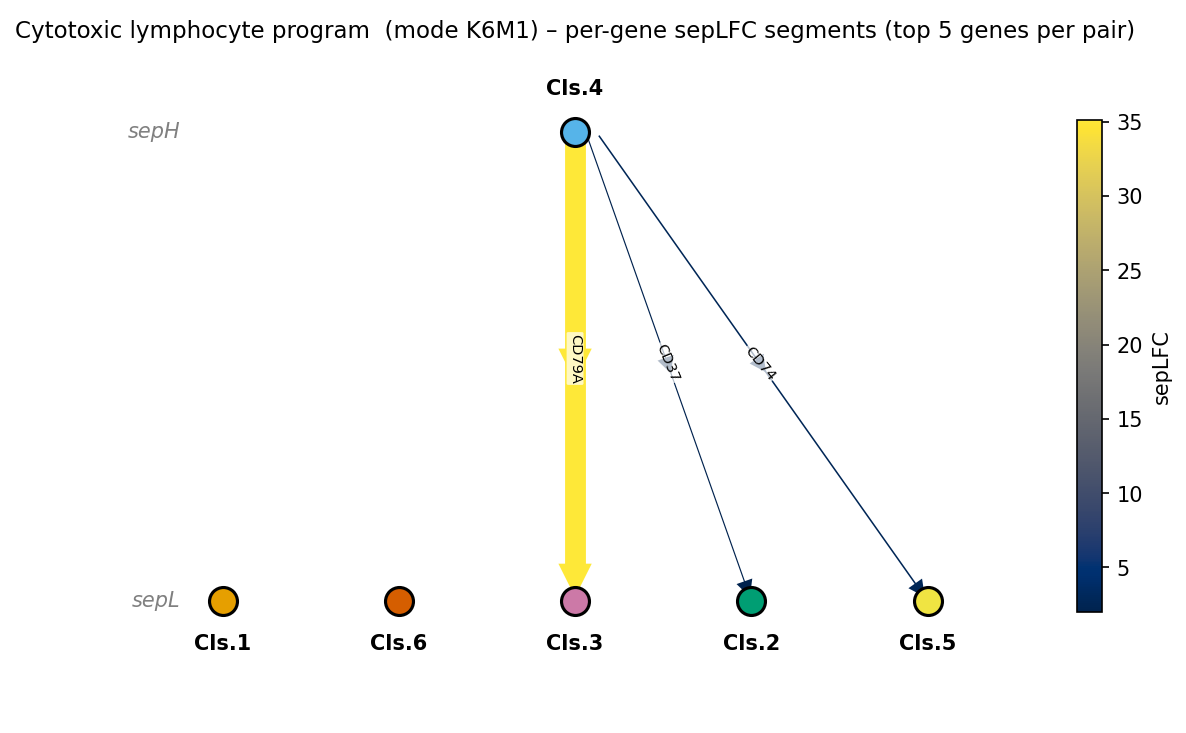

In [60]:
fig, ax = aoc.plot_seplfc_bipartite(
    gene_set, sep_res["sepH"], sep_res["sepL"], cluster_labels,
    df_mode=df_mode,
    top_n_per_pair=5,
    gs_title=gs_title,
    colors=cluster_colors,
    cmap='cividis',
    figsize=(8, 5),
)

---
## Across All Modes

Repeats the full enrichment pipeline (P enrichment, pairwise LFC, sepLFC) independently
for each alignment mode.

In [61]:
res_by_mode = aoc.run_gs_enrichment(
    sub_full, gene_set_indices, sub_full.modes, n_perm, rng_seed
)

### P Enrichment

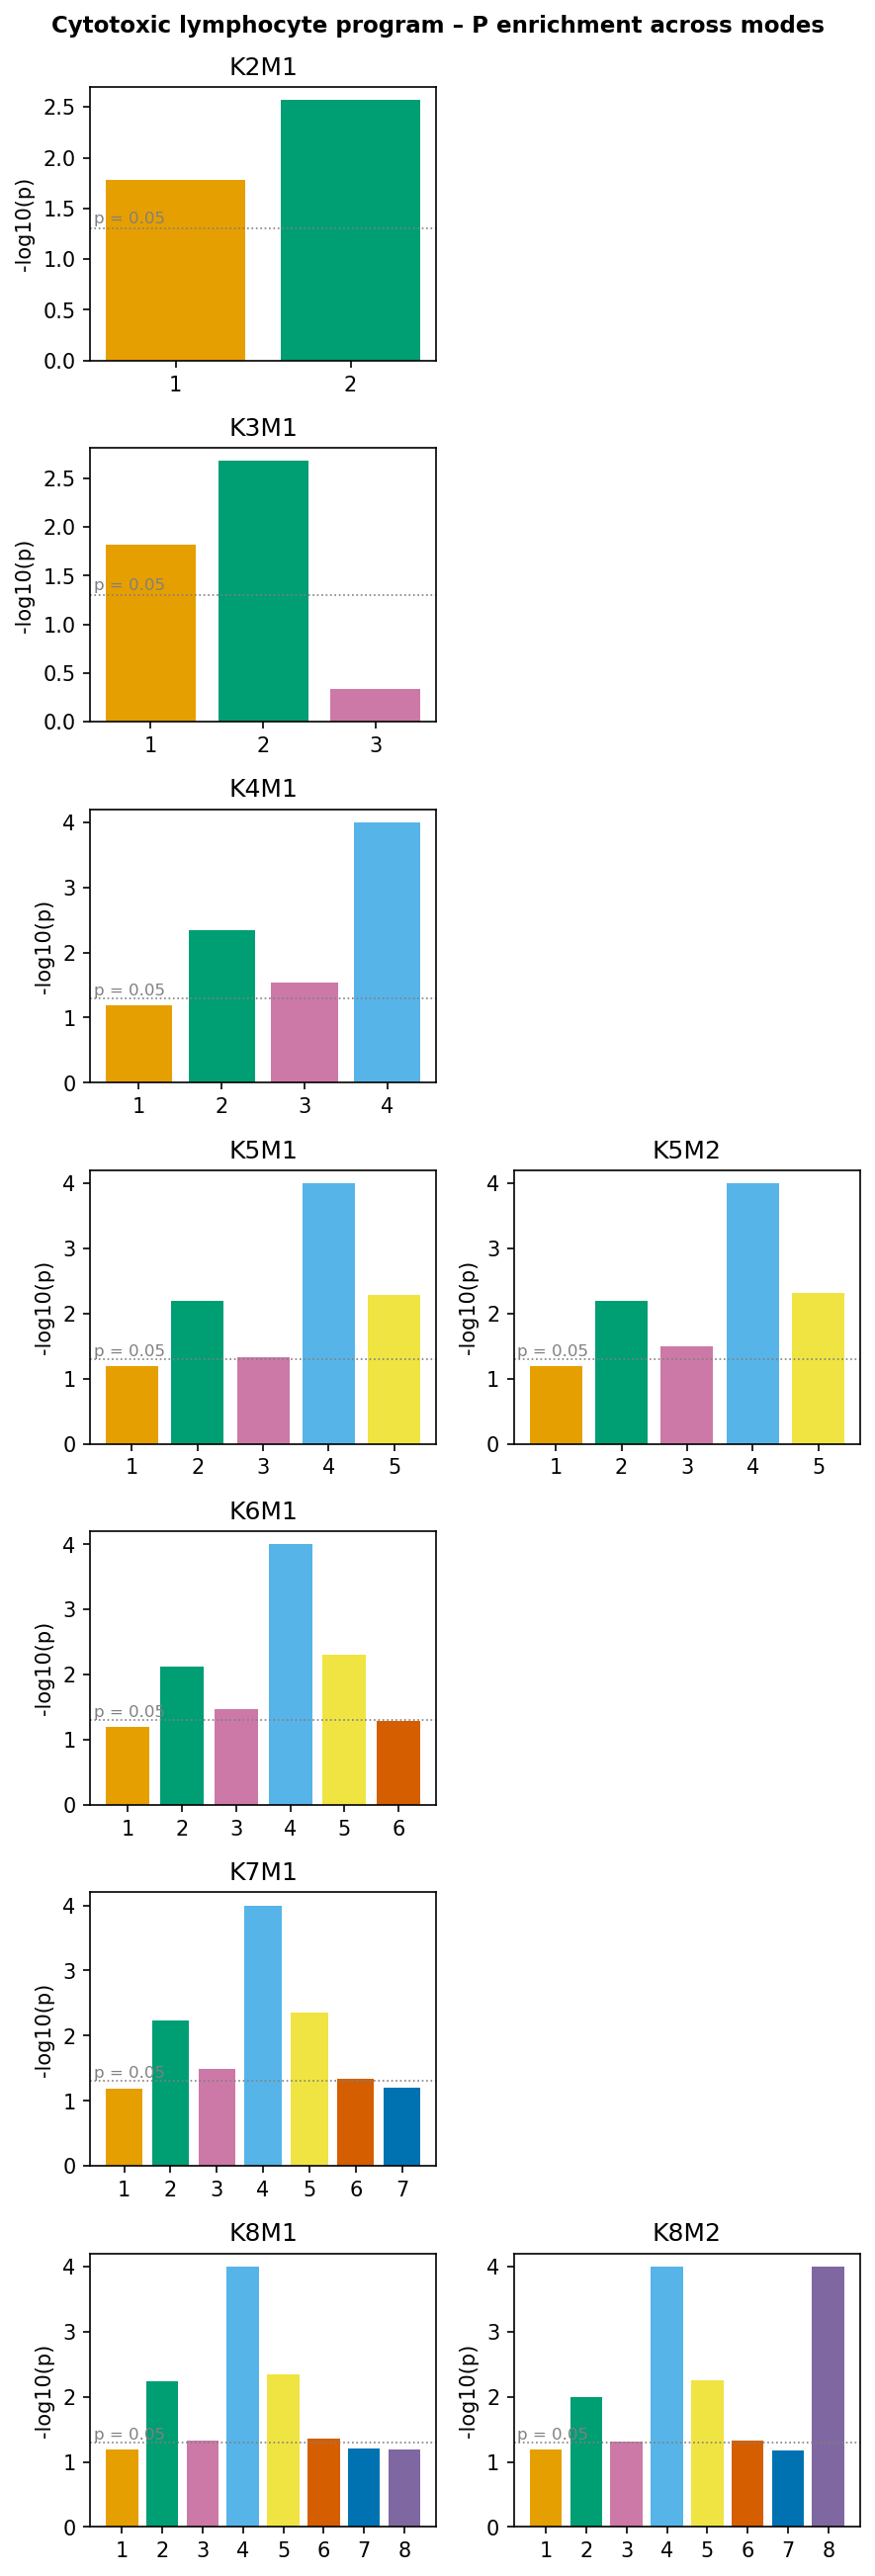

In [62]:
fig, ax_by_mode = make_mode_grid_by_K(sub_full)
aoc.plot_P_enrichment_grid(res_by_mode, ax_by_mode, sub_full, cb_cmap, kind="pval")
fig.suptitle(f"{gs_name} – P enrichment across modes", fontsize=11, weight="bold", y=0.99)
fig.tight_layout()

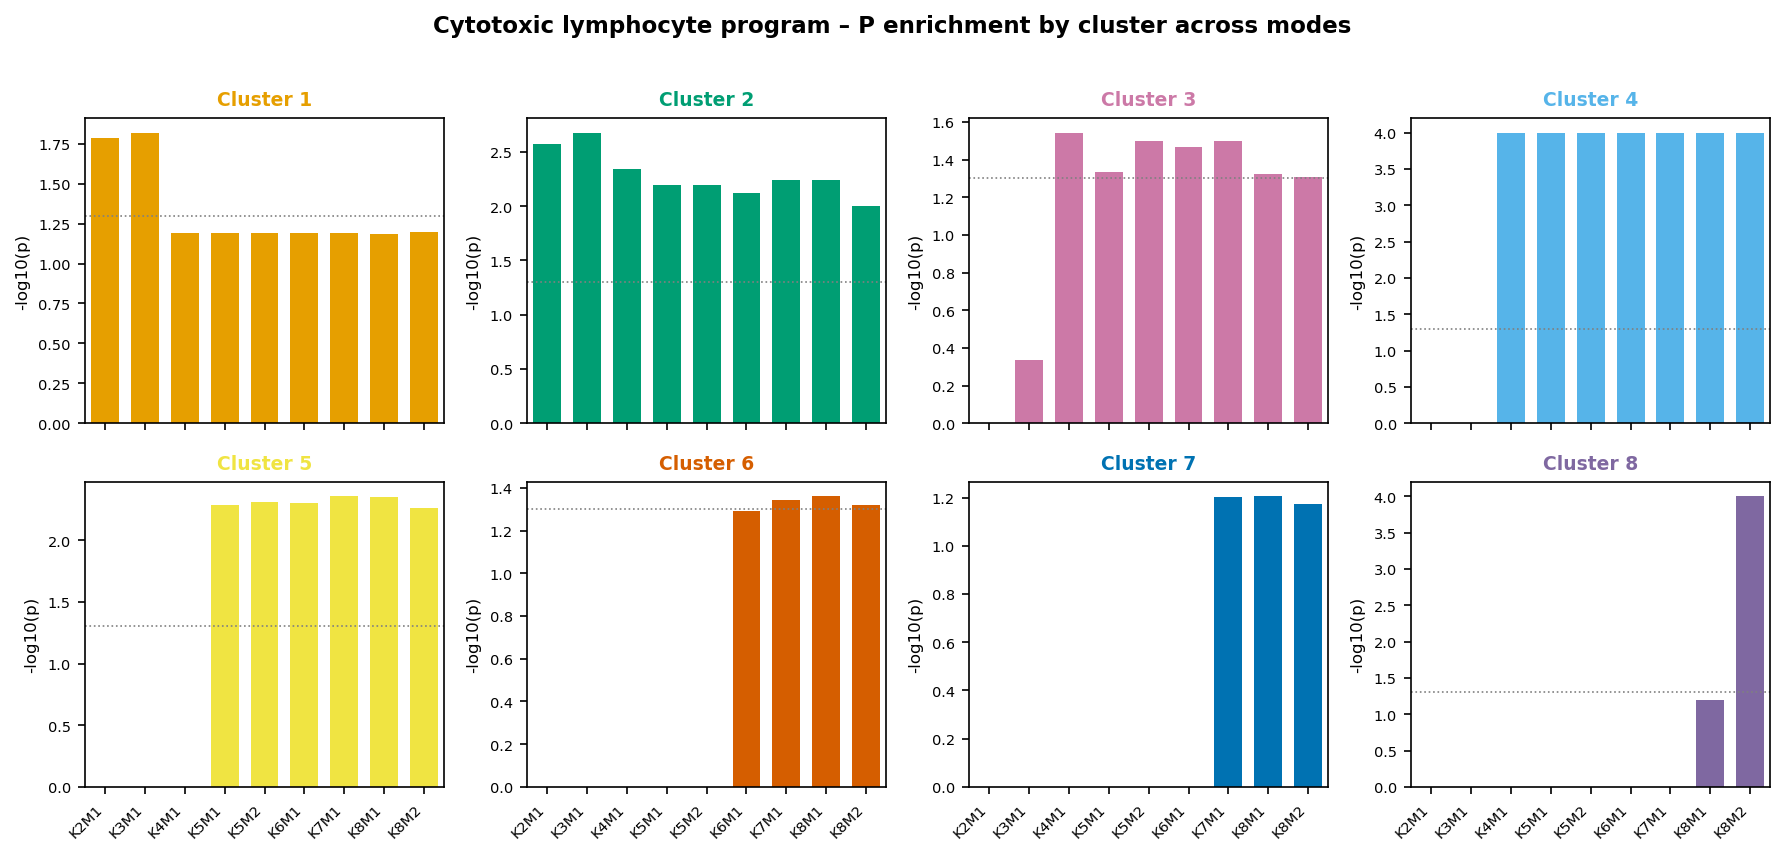

In [63]:
fig, axes = aoc.plot_P_enrichment_by_cluster(
    res_by_mode, sub_full, cb_cmap, kind="pval", ncols=4, sig_threshold=0.05
)
fig.suptitle(f"{gs_name} – P enrichment by cluster across modes",
             fontsize=11, weight="bold", y=1.01)
fig.tight_layout()

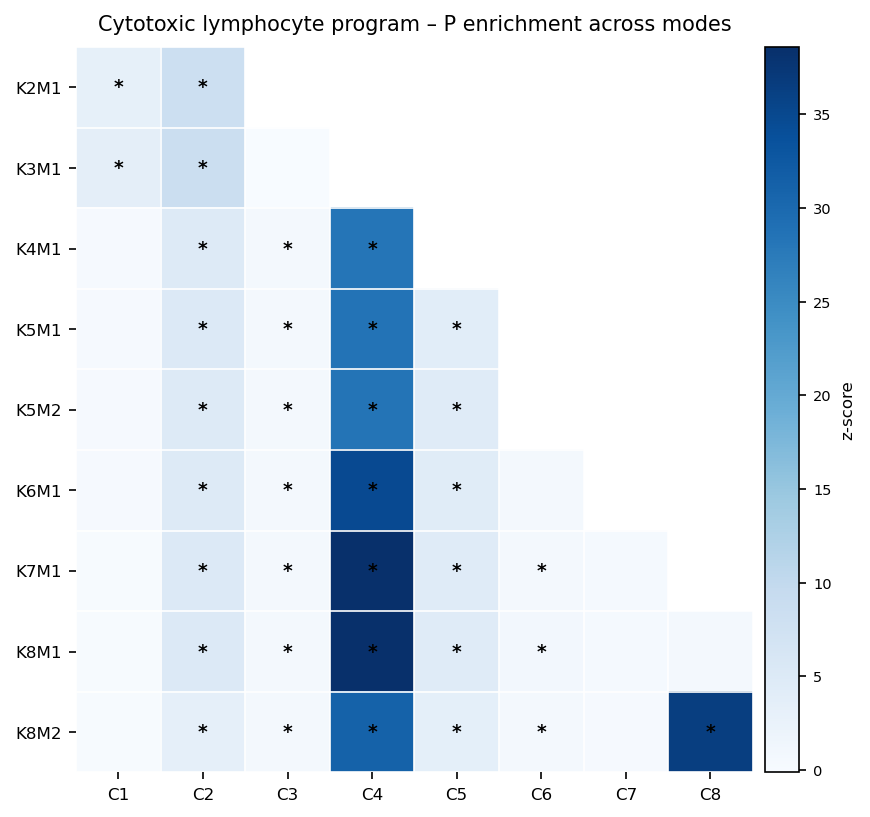

In [64]:
fig, ax = aoc.plot_P_enrichment_heatmap(
    res_by_mode, sub_full, value="z",
    title=f"{gs_name} – P enrichment across modes",
    cmap="Blues",
)

### Pairwise LFC

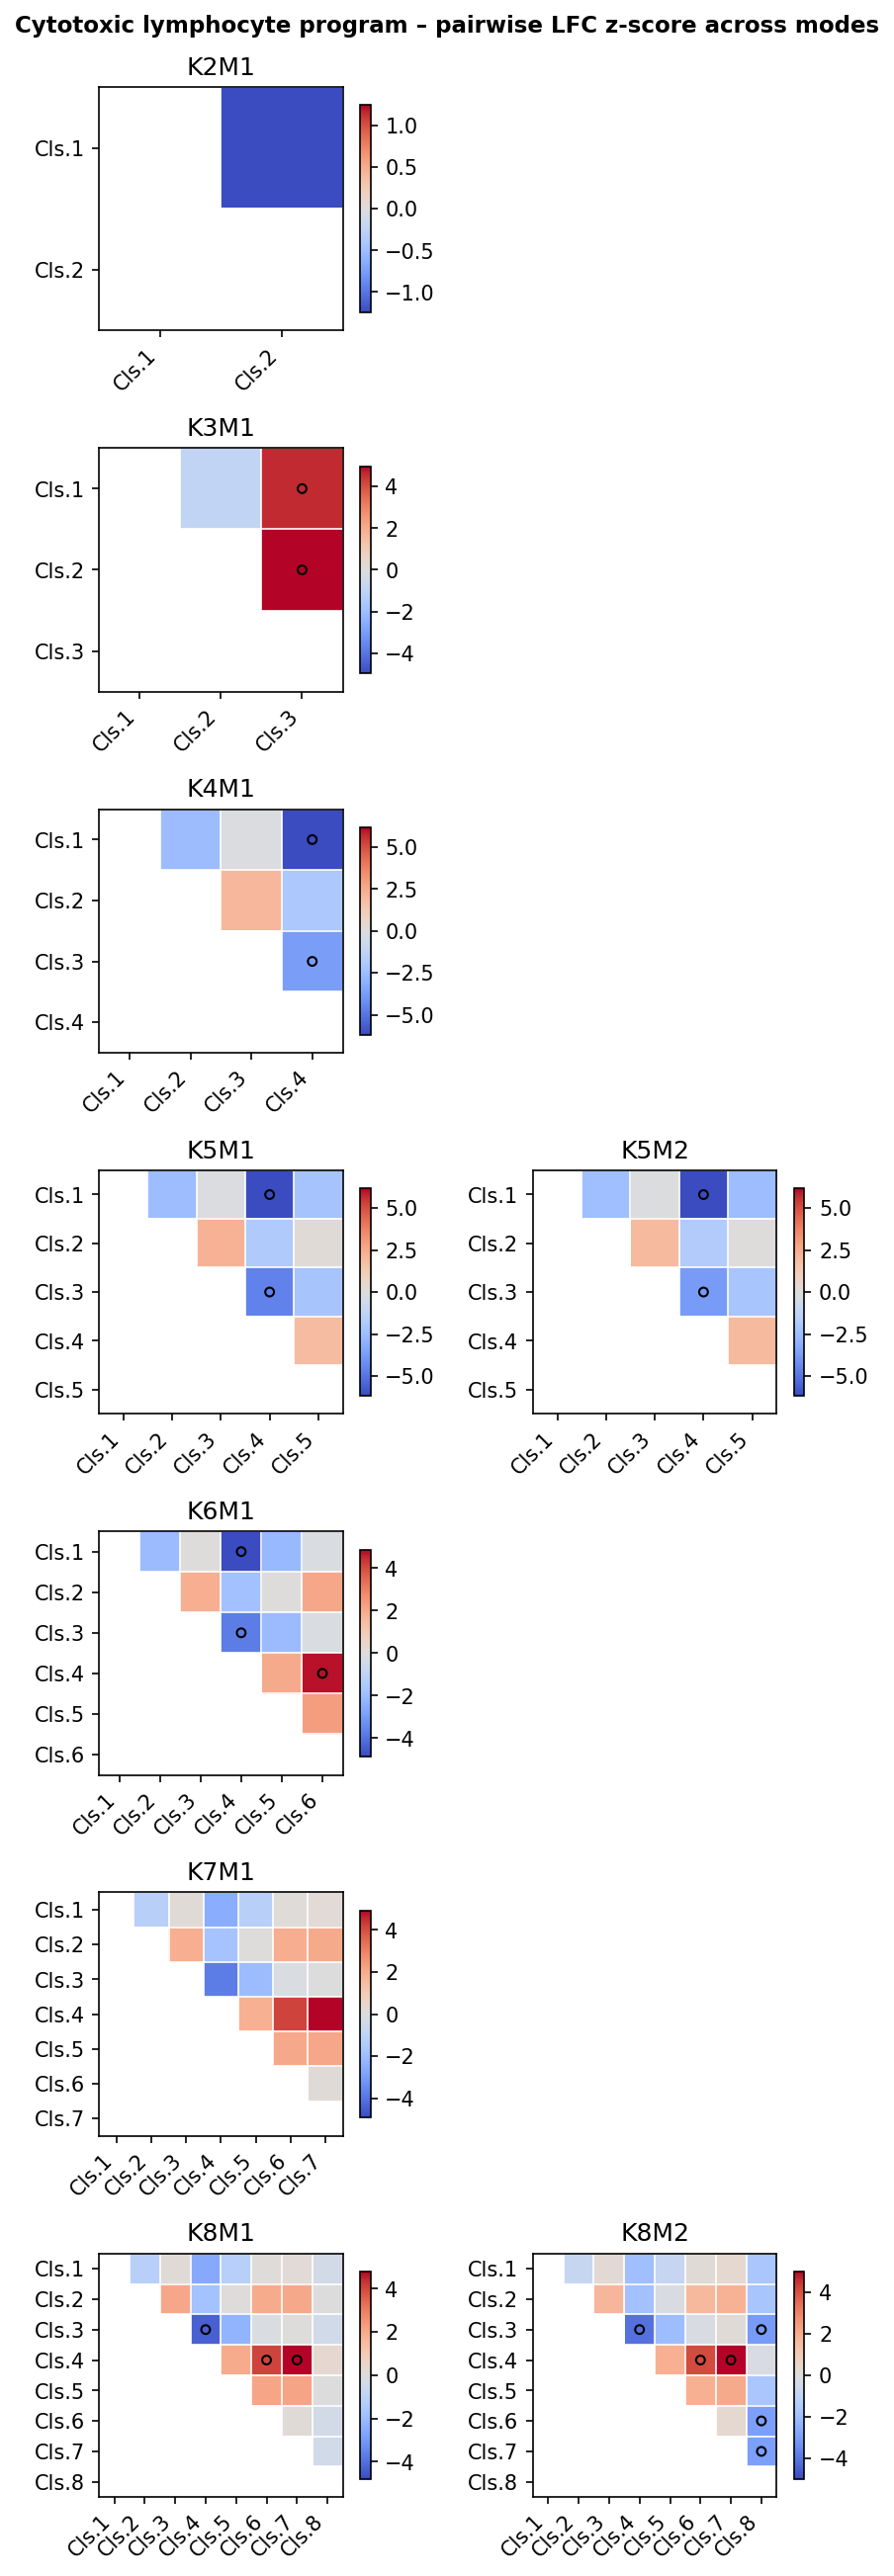

In [65]:
fig, ax_by_mode = make_mode_grid_by_K(sub_full)
aoc.plot_LFC_enrichment_grid(res_by_mode, ax_by_mode, sub_full, cb_cmap)
fig.suptitle(f"{gs_name} – pairwise LFC z-score across modes", fontsize=11, weight="bold", y=0.99)
fig.tight_layout()

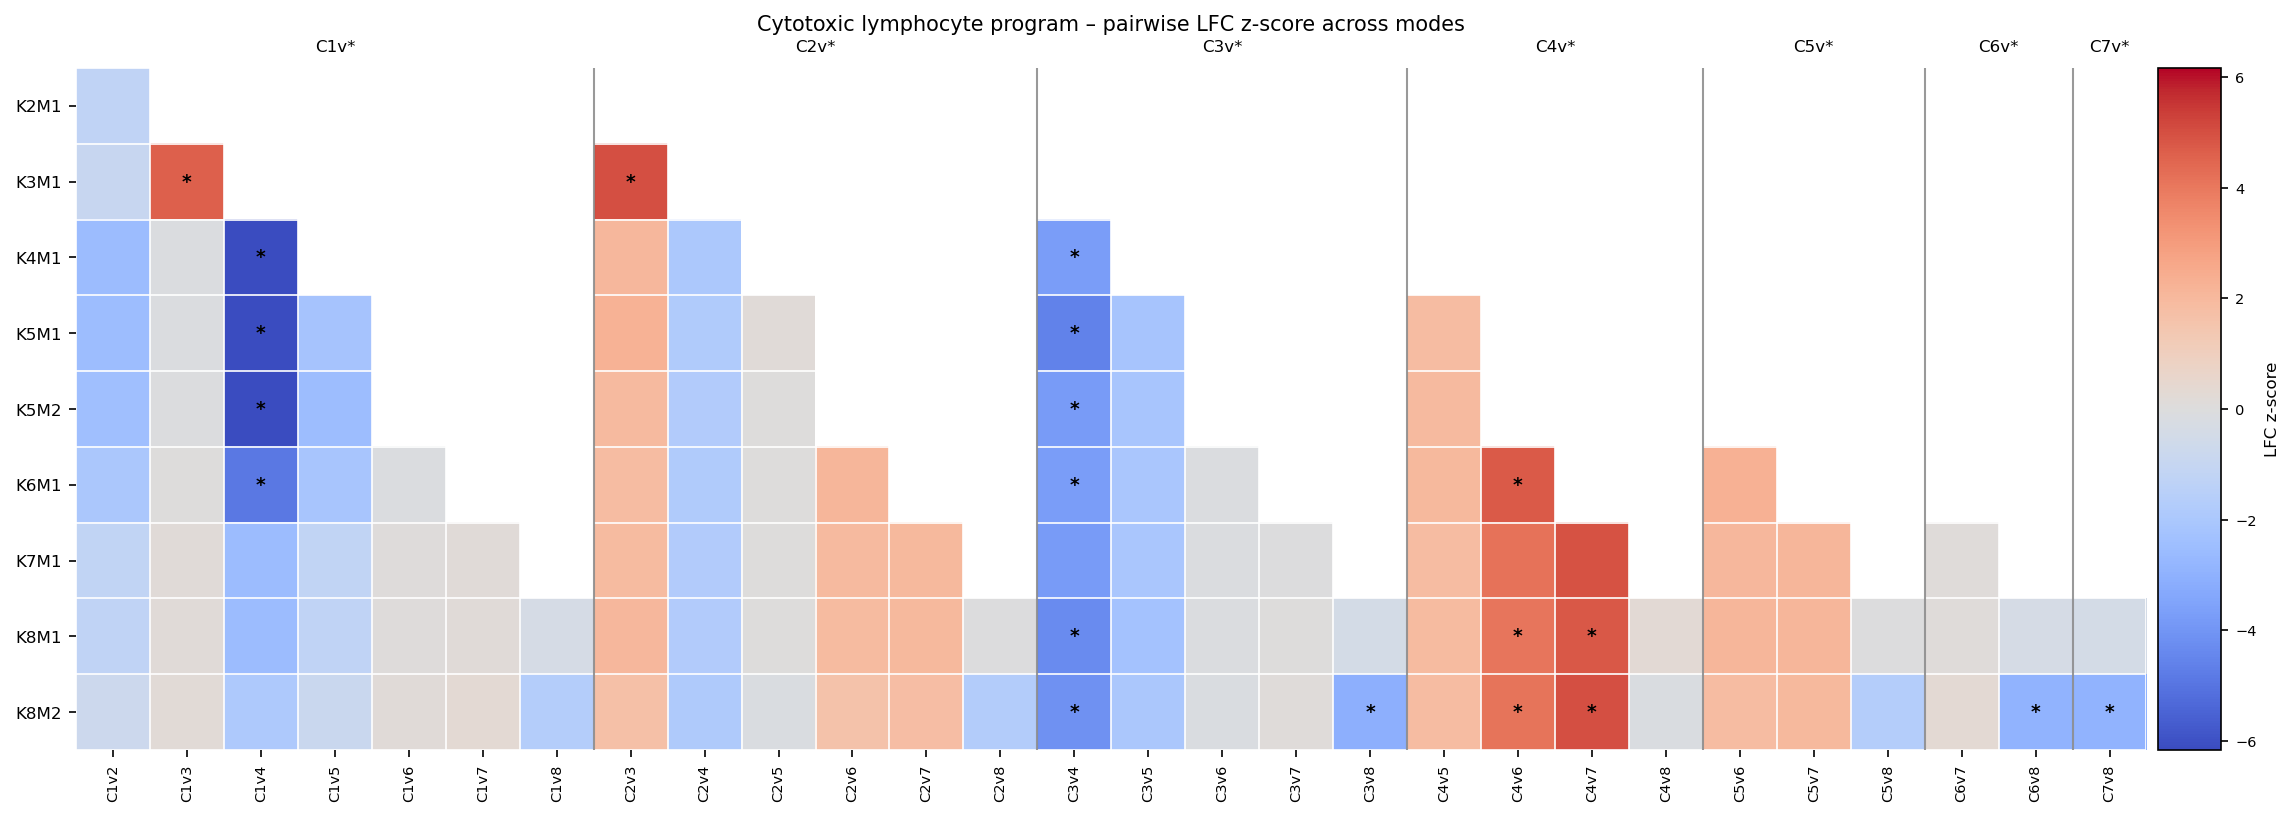

In [66]:
fig, ax = aoc.plot_LFC_enrichment_heatmap(
    res_by_mode, sub_full, value="z",
    title=f"{gs_name} – pairwise LFC z-score across modes",
)

### sepLFC

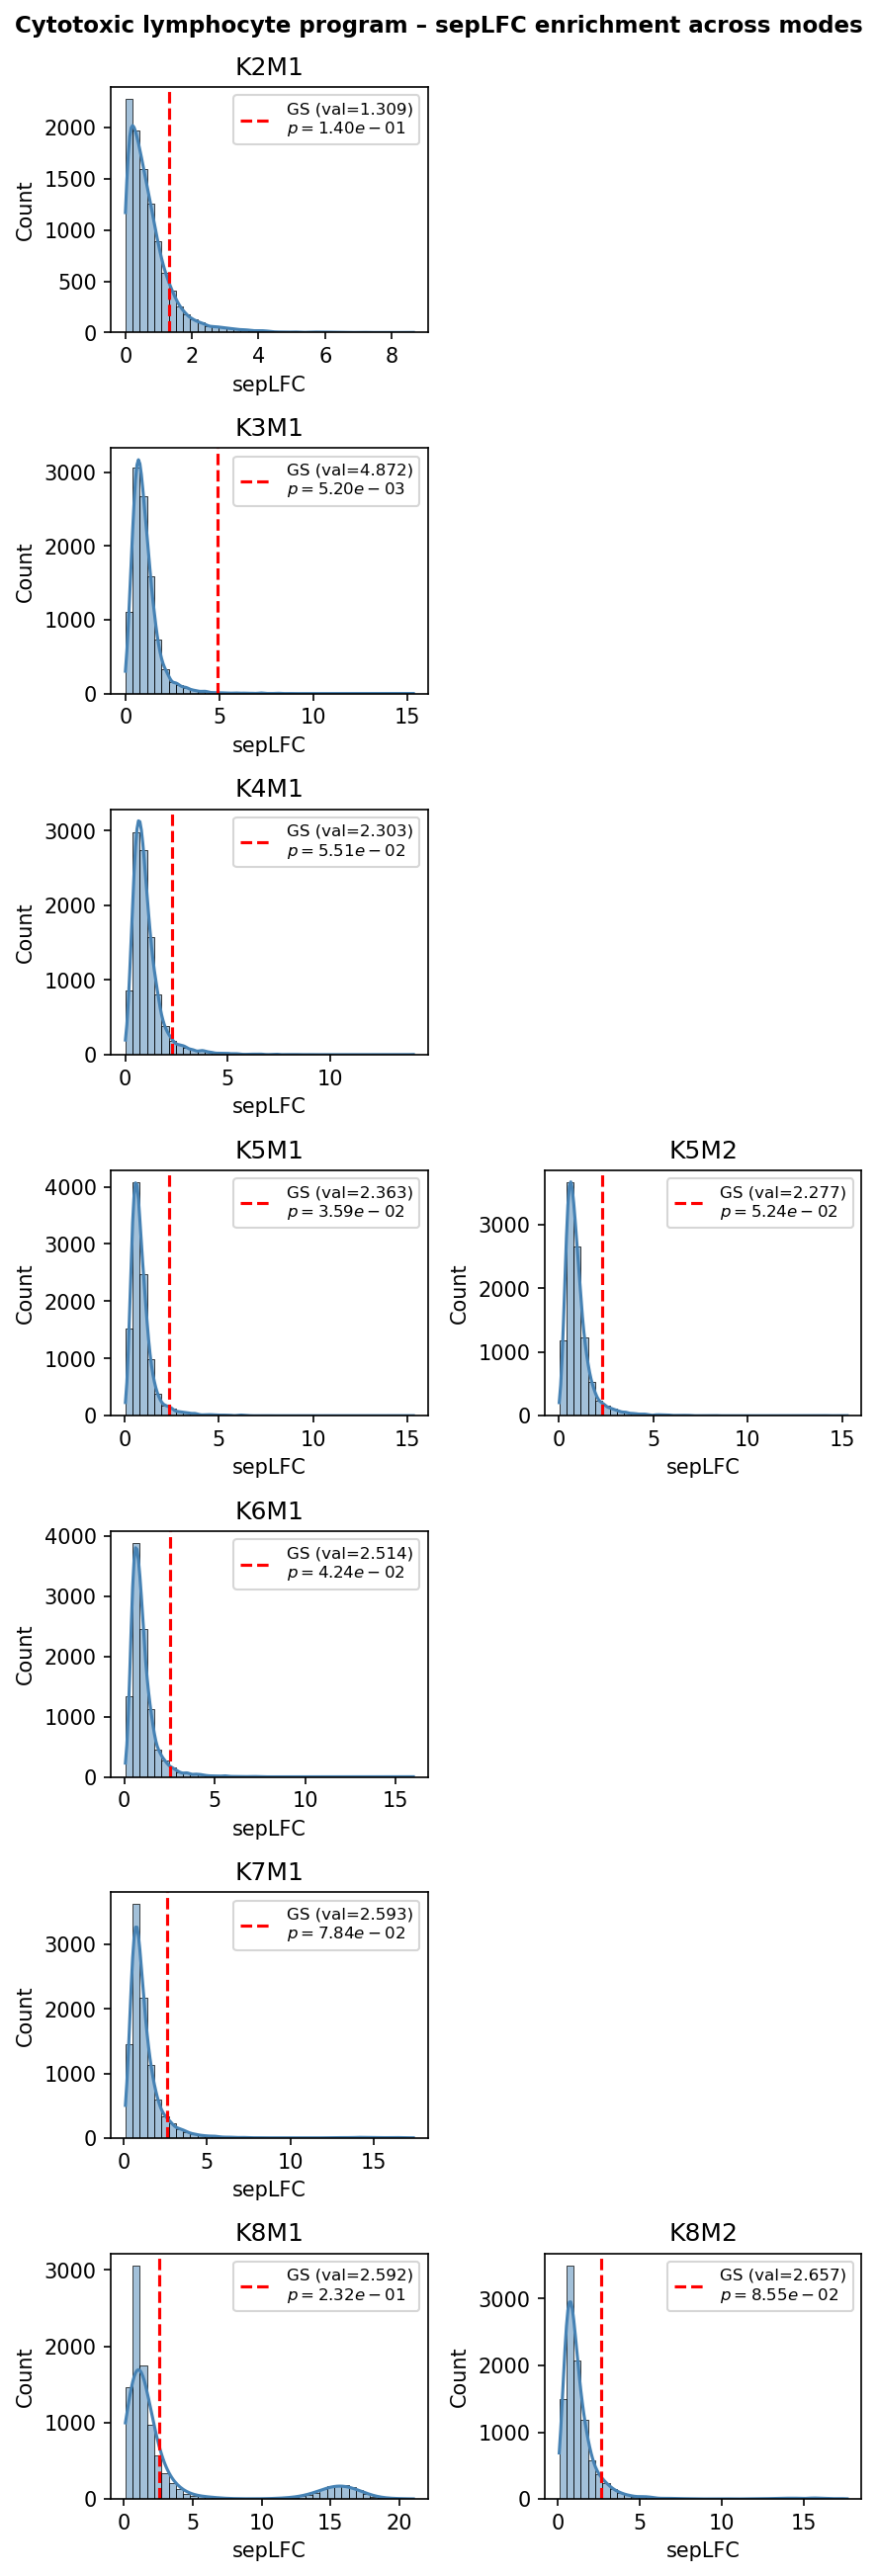

In [67]:
fig, ax_by_mode = make_mode_grid_by_K(sub_full)
aoc.plot_sepLFC_enrichment_grid(res_by_mode, ax_by_mode, sub_full, cb_cmap, kind="null_sep")
fig.suptitle(f"{gs_name} – sepLFC enrichment across modes", fontsize=11, weight="bold", y=0.99)
fig.tight_layout()

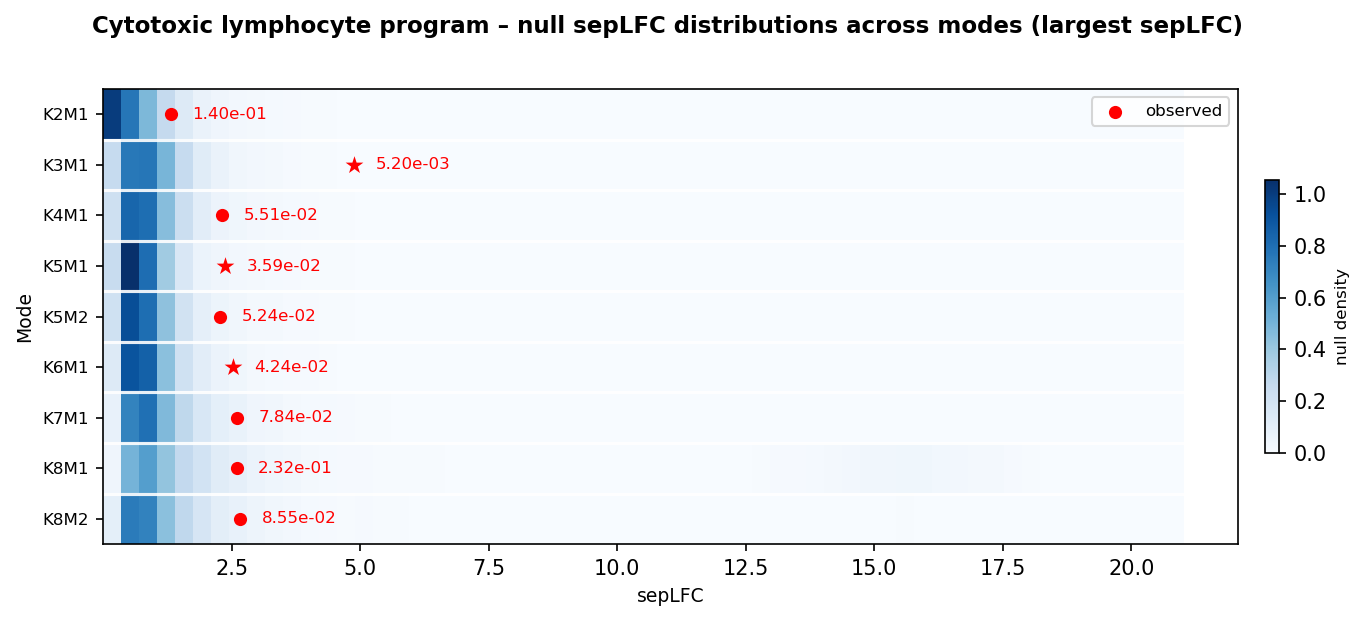

In [68]:
fig, _ = aoc.plot_sepLFC_distribution_heatmap(
    res_by_mode, n_bins=60, kind='null_sep', pval_threshold=0.05, annotate_pval=True
)
fig.suptitle(f"{gs_name} – null sepLFC distributions across modes (largest sepLFC)",
             fontsize=11, weight="bold", x=0.45, y=1.01)
fig.tight_layout()

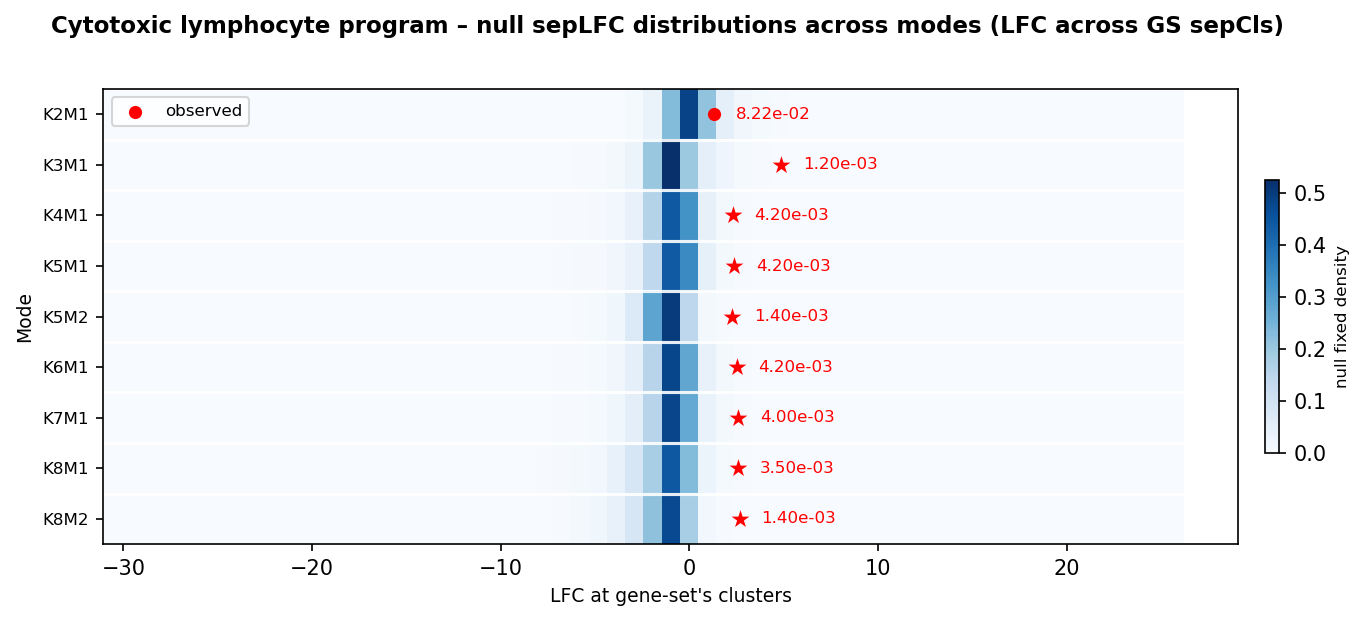

In [69]:
fig, _ = aoc.plot_sepLFC_distribution_heatmap(
    res_by_mode, n_bins=60, kind='null_fixed', pval_threshold=0.05, annotate_pval=True
)
fig.suptitle(f"{gs_name} – null sepLFC distributions across modes (LFC across GS sepCls)",
             fontsize=11, weight="bold", x=0.45, y=1.01)
fig.tight_layout()